In [1]:
!pip install -q ultralytics opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 3.6 MB/s eta 0:00:00


In [2]:
import ultralytics
import torch
import cv2

print("Ultralytics:", ultralytics.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.120
GPU available: True
GPU: Tesla T4


In [3]:
import os

video_path = "/content/video_2026-08-13_11-11-28.mp4"

print("Exists:", os.path.exists(video_path))

Exists: True


In [4]:
import cv2

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps

print("Resolution:", width, "x", height)
print("Original FPS:", fps)
print("Total frames:", frame_count)
print("Duration:", round(duration, 2), "seconds")

cap.release()

Resolution: 720 x 1280
Original FPS: 29.058523826409957
Total frames: 2228
Duration: 76.67 seconds


In [5]:
from ultralytics import YOLO
import torch

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

yolov8 = YOLO("yolov8n.pt")
yolo11 = YOLO("yolo11n.pt")
yolo12 = YOLO("yolo12n.pt")

print("All three models loaded successfully.")

GPU: Tesla T4
All three models loaded successfully.


In [6]:
import cv2

cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

cap.release()

print("Frame captured:", ret)
print("Frame shape:", frame.shape)

Frame captured: True
Frame shape: (1280, 720, 3)


In [7]:
r8 = yolov8.predict(
    source=frame,
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)

r11 = yolo11.predict(
    source=frame,
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)

r12 = yolo12.predict(
    source=frame,
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)

print("YOLOv8 detections :", len(r8[0].boxes))
print("YOLO11 detections :", len(r11[0].boxes))
print("YOLO12 detections :", len(r12[0].boxes))

YOLOv8 detections : 3
YOLO11 detections : 1
YOLO12 detections : 3


In [8]:
import cv2
import numpy as np

# Video path
video_path = "/content/video_2026-08-13_11-11-28.mp4"

# Open video
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError(f"Could not open video: {video_path}")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Select 10 frames across the whole video
sample_indices = np.linspace(
    0,
    total_frames - 1,
    10,
    dtype=int
)

frames = []

for idx in sample_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ret, frame = cap.read()

    if ret:
        frames.append((idx, frame))

cap.release()

print("Total video frames:", total_frames)
print("Sampled frames:", len(frames))
print("Frame indices:", sample_indices)

# Run the three models
for idx, frame in frames:

    r8 = yolov8.predict(
        source=frame,
        imgsz=640,
        conf=0.10,
        device=0,
        verbose=False
    )

    r11 = yolo11.predict(
        source=frame,
        imgsz=640,
        conf=0.10,
        device=0,
        verbose=False
    )

    r12 = yolo12.predict(
        source=frame,
        imgsz=640,
        conf=0.10,
        device=0,
        verbose=False
    )

    print(
        f"Frame {idx}: "
        f"YOLOv8={len(r8[0].boxes)}, "
        f"YOLO11={len(r11[0].boxes)}, "
        f"YOLO12={len(r12[0].boxes)}"
    )

Total video frames: 2228
Sampled frames: 10
Frame indices: [   0  247  494  742  989 1237 1484 1732 1979 2227]
Frame 0: YOLOv8=5, YOLO11=3, YOLO12=4
Frame 247: YOLOv8=2, YOLO11=2, YOLO12=4
Frame 494: YOLOv8=3, YOLO11=3, YOLO12=2
Frame 742: YOLOv8=3, YOLO11=4, YOLO12=3
Frame 989: YOLOv8=4, YOLO11=4, YOLO12=4
Frame 1237: YOLOv8=1, YOLO11=1, YOLO12=0
Frame 1484: YOLOv8=2, YOLO11=1, YOLO12=3
Frame 1732: YOLOv8=3, YOLO11=3, YOLO12=1
Frame 1979: YOLOv8=1, YOLO11=2, YOLO12=2
Frame 2227: YOLOv8=6, YOLO11=6, YOLO12=6


In [9]:
import cv2
import time
import numpy as np

models = {
    "YOLOv8n": yolov8,
    "YOLO11n": yolo11,
    "YOLO12n": yolo12
}

video_path = "/content/video_2026-08-13_11-11-28.mp4"

results_speed = {}

for model_name, model in models.items():

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Warm-up
    ret, frame = cap.read()

    if ret:
        for _ in range(10):
            model.predict(
                source=frame,
                imgsz=640,
                conf=0.25,
                device=0,
                verbose=False
            )

    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    times = []
    detection_counts = []

    for i in range(total_frames):

        ret, frame = cap.read()

        if not ret:
            break

        start = time.perf_counter()

        result = model.predict(
            source=frame,
            imgsz=640,
            conf=0.25,
            device=0,
            verbose=False
        )

        end = time.perf_counter()

        times.append((end - start) * 1000)
        detection_counts.append(len(result[0].boxes))

    cap.release()

    avg_latency = np.mean(times)
    median_latency = np.median(times)
    fps = 1000 / avg_latency
    avg_detections = np.mean(detection_counts)

    results_speed[model_name] = {
        "Average Latency (ms)": avg_latency,
        "Median Latency (ms)": median_latency,
        "FPS": fps,
        "Average Detections/Frame": avg_detections
    }

    print(f"\n{model_name}")
    print(f"Average latency : {avg_latency:.2f} ms")
    print(f"Median latency  : {median_latency:.2f} ms")
    print(f"FPS              : {fps:.2f}")
    print(f"Avg detections   : {avg_detections:.2f}")


YOLOv8n
Average latency : 12.19 ms
Median latency  : 10.54 ms
FPS              : 82.04
Avg detections   : 1.35

YOLO11n
Average latency : 14.00 ms
Median latency  : 12.69 ms
FPS              : 71.41
Avg detections   : 1.26

YOLO12n
Average latency : 20.02 ms
Median latency  : 17.80 ms
FPS              : 49.94
Avg detections   : 1.33


In [10]:
import cv2
import numpy as np
import os

cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Early, middle, and late scenes
selected_indices = [
    int(total_frames * 0.15),
    int(total_frames * 0.50),
    int(total_frames * 0.85)
]

os.makedirs("/content/task2_samples", exist_ok=True)

for i, idx in enumerate(selected_indices):

    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()

    if ret:
        path = f"/content/task2_samples/scene_{i+1}.jpg"
        cv2.imwrite(path, frame)
        print(f"Scene {i+1}: frame {idx} -> {path}")

cap.release()

Scene 1: frame 334 -> /content/task2_samples/scene_1.jpg
Scene 2: frame 1114 -> /content/task2_samples/scene_2.jpg
Scene 3: frame 1893 -> /content/task2_samples/scene_3.jpg


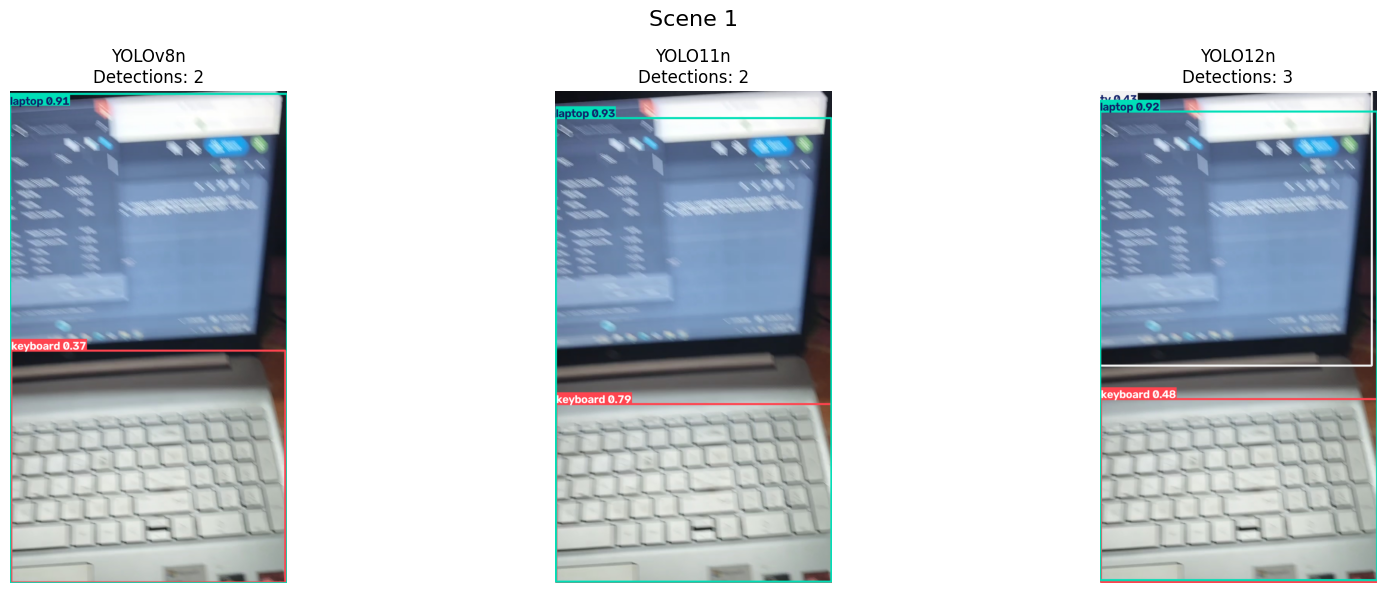

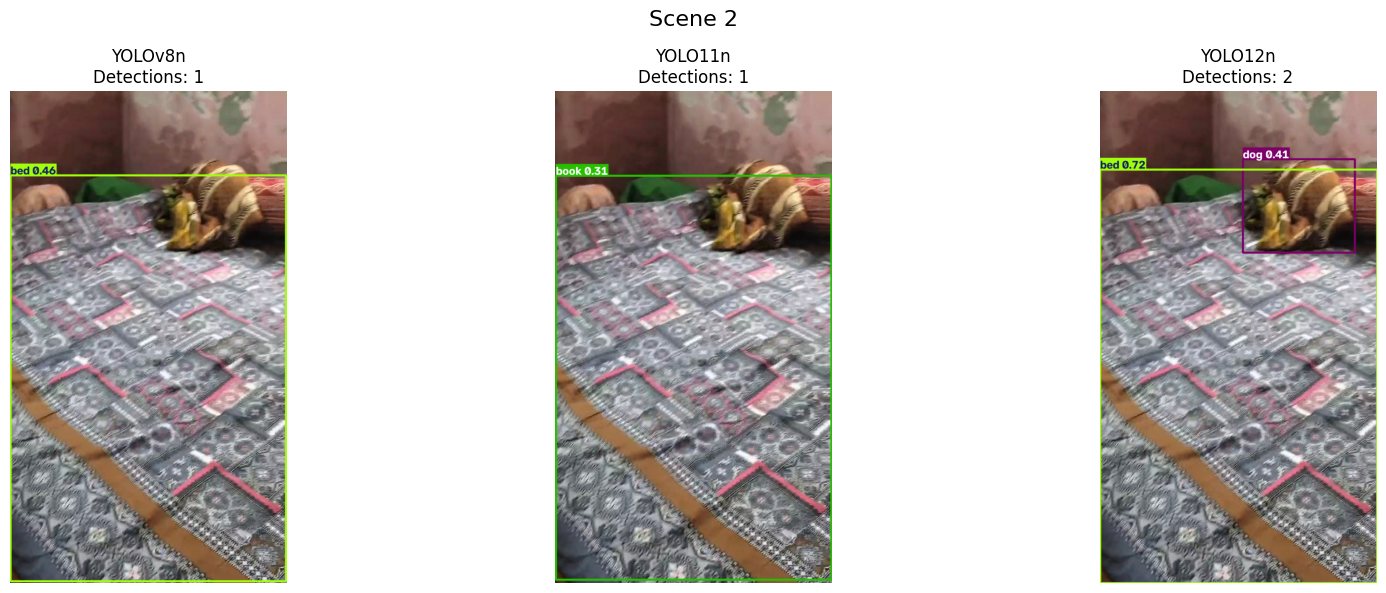

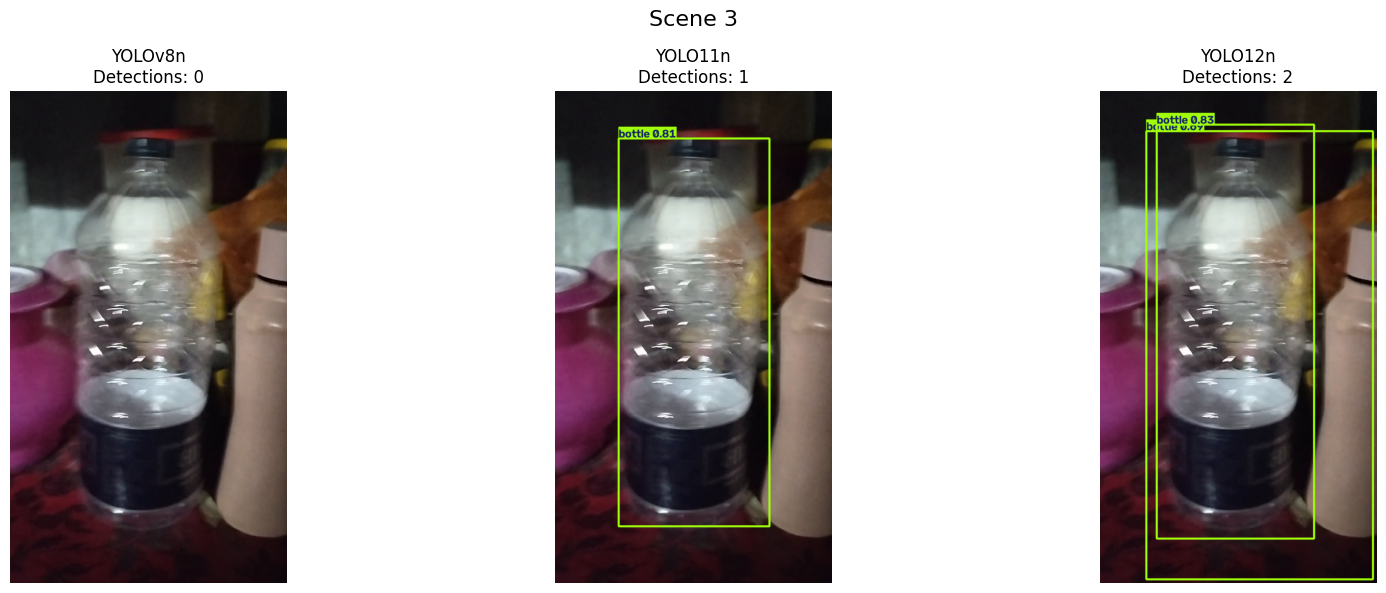

In [11]:
import cv2
import matplotlib.pyplot as plt
import os

scene_paths = [
    "/content/task2_samples/scene_1.jpg",
    "/content/task2_samples/scene_2.jpg",
    "/content/task2_samples/scene_3.jpg"
]

models = {
    "YOLOv8n": yolov8,
    "YOLO11n": yolo11,
    "YOLO12n": yolo12
}

for scene_no, path in enumerate(scene_paths, 1):

    frame = cv2.imread(path)

    if frame is None:
        print("Could not read:", path)
        continue

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, (model_name, model) in zip(axes, models.items()):

        result = model.predict(
            source=frame,
            imgsz=640,
            conf=0.25,
            device=0,
            verbose=False
        )[0]

        plotted = result.plot()

        axes[list(models.keys()).index(model_name)].imshow(
            cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
        )

        ax.set_title(
            f"{model_name}\n"
            f"Detections: {len(result.boxes)}"
        )
        ax.axis("off")

    plt.suptitle(f"Scene {scene_no}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [12]:
import os
from ultralytics import YOLO

video_path = "/content/video_2026-08-13_11-11-28.mp4"

os.makedirs("/content/task2_outputs", exist_ok=True)

models = {
    "YOLOv8n": yolov8,
    "YOLO11n": yolo11,
    "YOLO12n": yolo12
}

for name, model in models.items():

    folder_name = name.lower().replace("n", "")

    print(f"\nRunning {name}...")

    results = model.predict(
        source=video_path,
        imgsz=640,
        conf=0.25,
        device=0,
        save=True,
        stream=True,
        project="/content/task2_outputs",
        name=folder_name,
        exist_ok=True,
        verbose=False
    )

    # Important: consume the generator
    frame_count = 0

    for r in results:
        frame_count += 1

        if frame_count % 500 == 0:
            print(f"{name}: processed {frame_count} frames")

    print(f"{name} completed: {frame_count} frames")


Running YOLOv8n...
YOLOv8n: processed 500 frames
YOLOv8n: processed 1000 frames
YOLOv8n: processed 1500 frames
YOLOv8n: processed 2000 frames
Results saved to /content/task2_outputs/yolov8
YOLOv8n completed: 2228 frames

Running YOLO11n...
YOLO11n: processed 500 frames
YOLO11n: processed 1000 frames
YOLO11n: processed 1500 frames
YOLO11n: processed 2000 frames
Results saved to /content/task2_outputs/yolo11
YOLO11n completed: 2228 frames

Running YOLO12n...
YOLO12n: processed 500 frames
YOLO12n: processed 1000 frames
YOLO12n: processed 1500 frames
YOLO12n: processed 2000 frames
Results saved to /content/task2_outputs/yolo12
YOLO12n completed: 2228 frames


In [13]:
!pip install -q ultralytics

from ultralytics import YOLO

yolov8 = YOLO("yolov8n.pt")
yolo11 = YOLO("yolo11n.pt")
yolo12 = YOLO("yolo12n.pt")

In [14]:
import cv2
import os

video_path = "/content/video_2026-08-13_11-11-28.mp4"

def make_video(model, name):

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    os.makedirs("/content/task2_outputs", exist_ok=True)

    out = cv2.VideoWriter(
        f"/content/task2_outputs/{name}.mp4",
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w, h)
    )

    count = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        result = model.predict(
            frame,
            imgsz=640,
            conf=0.25,
            device=0,
            verbose=False
        )[0]

        out.write(result.plot())

        count += 1

        if count % 500 == 0:
            print(name, count)

    cap.release()
    out.release()

    print(name, "DONE")

make_video(yolov8, "YOLOv8")
make_video(yolo11, "YOLO11")
make_video(yolo12, "YOLO12")

YOLOv8 500
YOLOv8 1000
YOLOv8 1500
YOLOv8 2000
YOLOv8 DONE
YOLO11 500
YOLO11 1000
YOLO11 1500
YOLO11 2000
YOLO11 DONE
YOLO12 500
YOLO12 1000
YOLO12 1500
YOLO12 2000
YOLO12 DONE


In [15]:
!git clone https://github.com/lindevs/yolov8-face.git
%cd yolov8-face
!pip install -q -r requirements.txt

Cloning into 'yolov8-face'...
remote: Enumerating objects: 165, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 165 (delta 27), reused 27 (delta 23), pack-reused 129 (from 1)
Receiving objects: 100% (165/165), 4.47 MiB | 11.08 MiB/s, done.
Resolving deltas: 100% (54/54), done.
/content/yolov8-face


In [16]:
!python download.py

https://huggingface.co/datasets/wider_face/resolve/main/data/WIDER_train.zip
1398 MiB/1398 MiB (100%) - 26.04 MiB/s - 54 seconds passed
https://huggingface.co/datasets/wider_face/resolve/main/data/WIDER_val.zip
346 MiB/346 MiB (100%) - 27.14 MiB/s - 13 seconds passed
https://huggingface.co/datasets/wider_face/resolve/main/data/wider_face_split.zip
3 MiB/3 MiB (100%) - 6.08 MiB/s - 1 seconds passed


In [17]:
!python annotations.py

In [ ]:
!cp widerface.yaml.example widerface.yaml

cp: cannot stat 'widerface.yaml.example': No such file or directory


In [18]:
!python data_file.py

In [19]:
!cat data/widerface.yaml

path: /content/yolov8-face/data/widerface
train: train
val: val
test:

names:
  0: face


In [20]:
!find data/widerface/train/images -type f | wc -l
!find data/widerface/train/labels -type f | wc -l

!find data/widerface/val/images -type f | wc -l
!find data/widerface/val/labels -type f | wc -l

find: ‘data/widerface/train/images’: No such file or directory
0
find: ‘data/widerface/train/labels’: No such file or directory
0
find: ‘data/widerface/val/images’: No such file or directory
0
find: ‘data/widerface/val/labels’: No such file or directory
0


In [21]:
!find /content/yolov8-face/data/widerface -maxdepth 2 -type d

/content/yolov8-face/data/widerface
/content/yolov8-face/data/widerface/train
/content/yolov8-face/data/widerface/val


In [22]:
!find /content/yolov8-face/data/widerface/train -type f | wc -l
!find /content/yolov8-face/data/widerface/val -type f | wc -l

25760
6452


In [23]:
from pathlib import Path
import yaml

WIDER_DATA = Path("/content/yolov8-face/data/widerface")

assert (WIDER_DATA / "train").exists()
assert (WIDER_DATA / "val").exists()

WIDER_YAML = Path("/content/widerface_assignment8.yaml")

WIDER_YAML.write_text(
    yaml.safe_dump({
        "path": str(WIDER_DATA),
        "train": "train",
        "val": "val",
        "nc": 1,
        "names": {0: "face"}
    }, sort_keys=False)
)

print(WIDER_YAML.read_text())

path: /content/yolov8-face/data/widerface
train: train
val: val
nc: 1
names:
  0: face



In [24]:
from ultralytics import YOLO

face_model = YOLO("yolov8n.pt")

face_train = face_model.train(
    data="/content/yolov8-face/data/widerface.yaml",
    epochs=5,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    patience=10,
    project="/content/runs/assignment8",
    name="widerface_yolov8n",
    pretrained=True,
    plots=True
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolov8-face/data/widerface.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=widerface_yolov8n, nb

In [25]:
trained_face = YOLO(
    "/content/runs/assignment8/widerface_yolov8n/weights/best.pt"
)

face_val = trained_face.val(
    data="/content/yolov8-face/data/widerface.yaml",
    split="val",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2790.3±1034.4 MB/s, size: 117.2 KB)
val: Scanning /content/yolov8-face/data/widerface/val.cache... 3226 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3226/3226 712.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 202/202 5.2it/s 38.5s
                   all       3226      39706      0.807      0.529      0.596       0.31
Speed: 1.1ms preprocess, 3.6ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/yolov8-face/runs/detect/val


In [26]:
from pathlib import Path
import urllib.request
from ultralytics import YOLO

LINDEVS_WEIGHTS = Path("/content/yolov8n-face-lindevs.pt")

if not LINDEVS_WEIGHTS.exists():
    urllib.request.urlretrieve(
        "https://github.com/lindevs/yolov8-face/releases/latest/download/yolov8n-face-lindevs.pt",
        LINDEVS_WEIGHTS
    )

public_face = YOLO(str(LINDEVS_WEIGHTS))

public_face_val = public_face.val(
    data="/content/yolov8-face/data/widerface.yaml",
    split="val",
    device=0,
    imgsz=640,
    plots=True
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2078.8±822.2 MB/s, size: 93.5 KB)
val: Scanning /content/yolov8-face/data/widerface/val.cache... 3226 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3226/3226 751.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 202/202 5.7it/s 35.5s
                   all       3226      39706      0.857      0.594      0.661      0.359
Speed: 1.1ms preprocess, 2.8ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/yolov8-face/runs/detect/val-2


In [27]:
import pandas as pd
import numpy as np

def get_metrics(name, m):
    return {
        "model": name,
        "precision": float(m.box.mp),
        "recall": float(m.box.mr),
        "mAP50": float(m.box.map50),
        "mAP50_95": float(m.box.map),
        "preprocess_ms": float(m.speed.get("preprocess", np.nan)),
        "inference_ms": float(m.speed.get("inference", np.nan)),
        "postprocess_ms": float(m.speed.get("postprocess", np.nan))
    }

face_comparison = pd.DataFrame([
    get_metrics("Our fine-tuned YOLOv8n", face_val),
    get_metrics("Lindevs YOLOv8n-Face", public_face_val)
])

face_comparison["total_latency_ms"] = (
    face_comparison["preprocess_ms"] +
    face_comparison["inference_ms"] +
    face_comparison["postprocess_ms"]
)

display(face_comparison.round(4))

,model,precision,recall,mAP50,mAP50_95,preprocess_ms,inference_ms,postprocess_ms,total_latency_ms
0,Our fine-tuned YOLOv8n,0.8068,0.5292,0.5965,0.3100,1.1457,3.6049,1.6349,6.3854
1,Lindevs YOLOv8n-Face,0.8567,0.5945,0.6613,0.3591,1.1045,2.8032,1.6485,5.5562


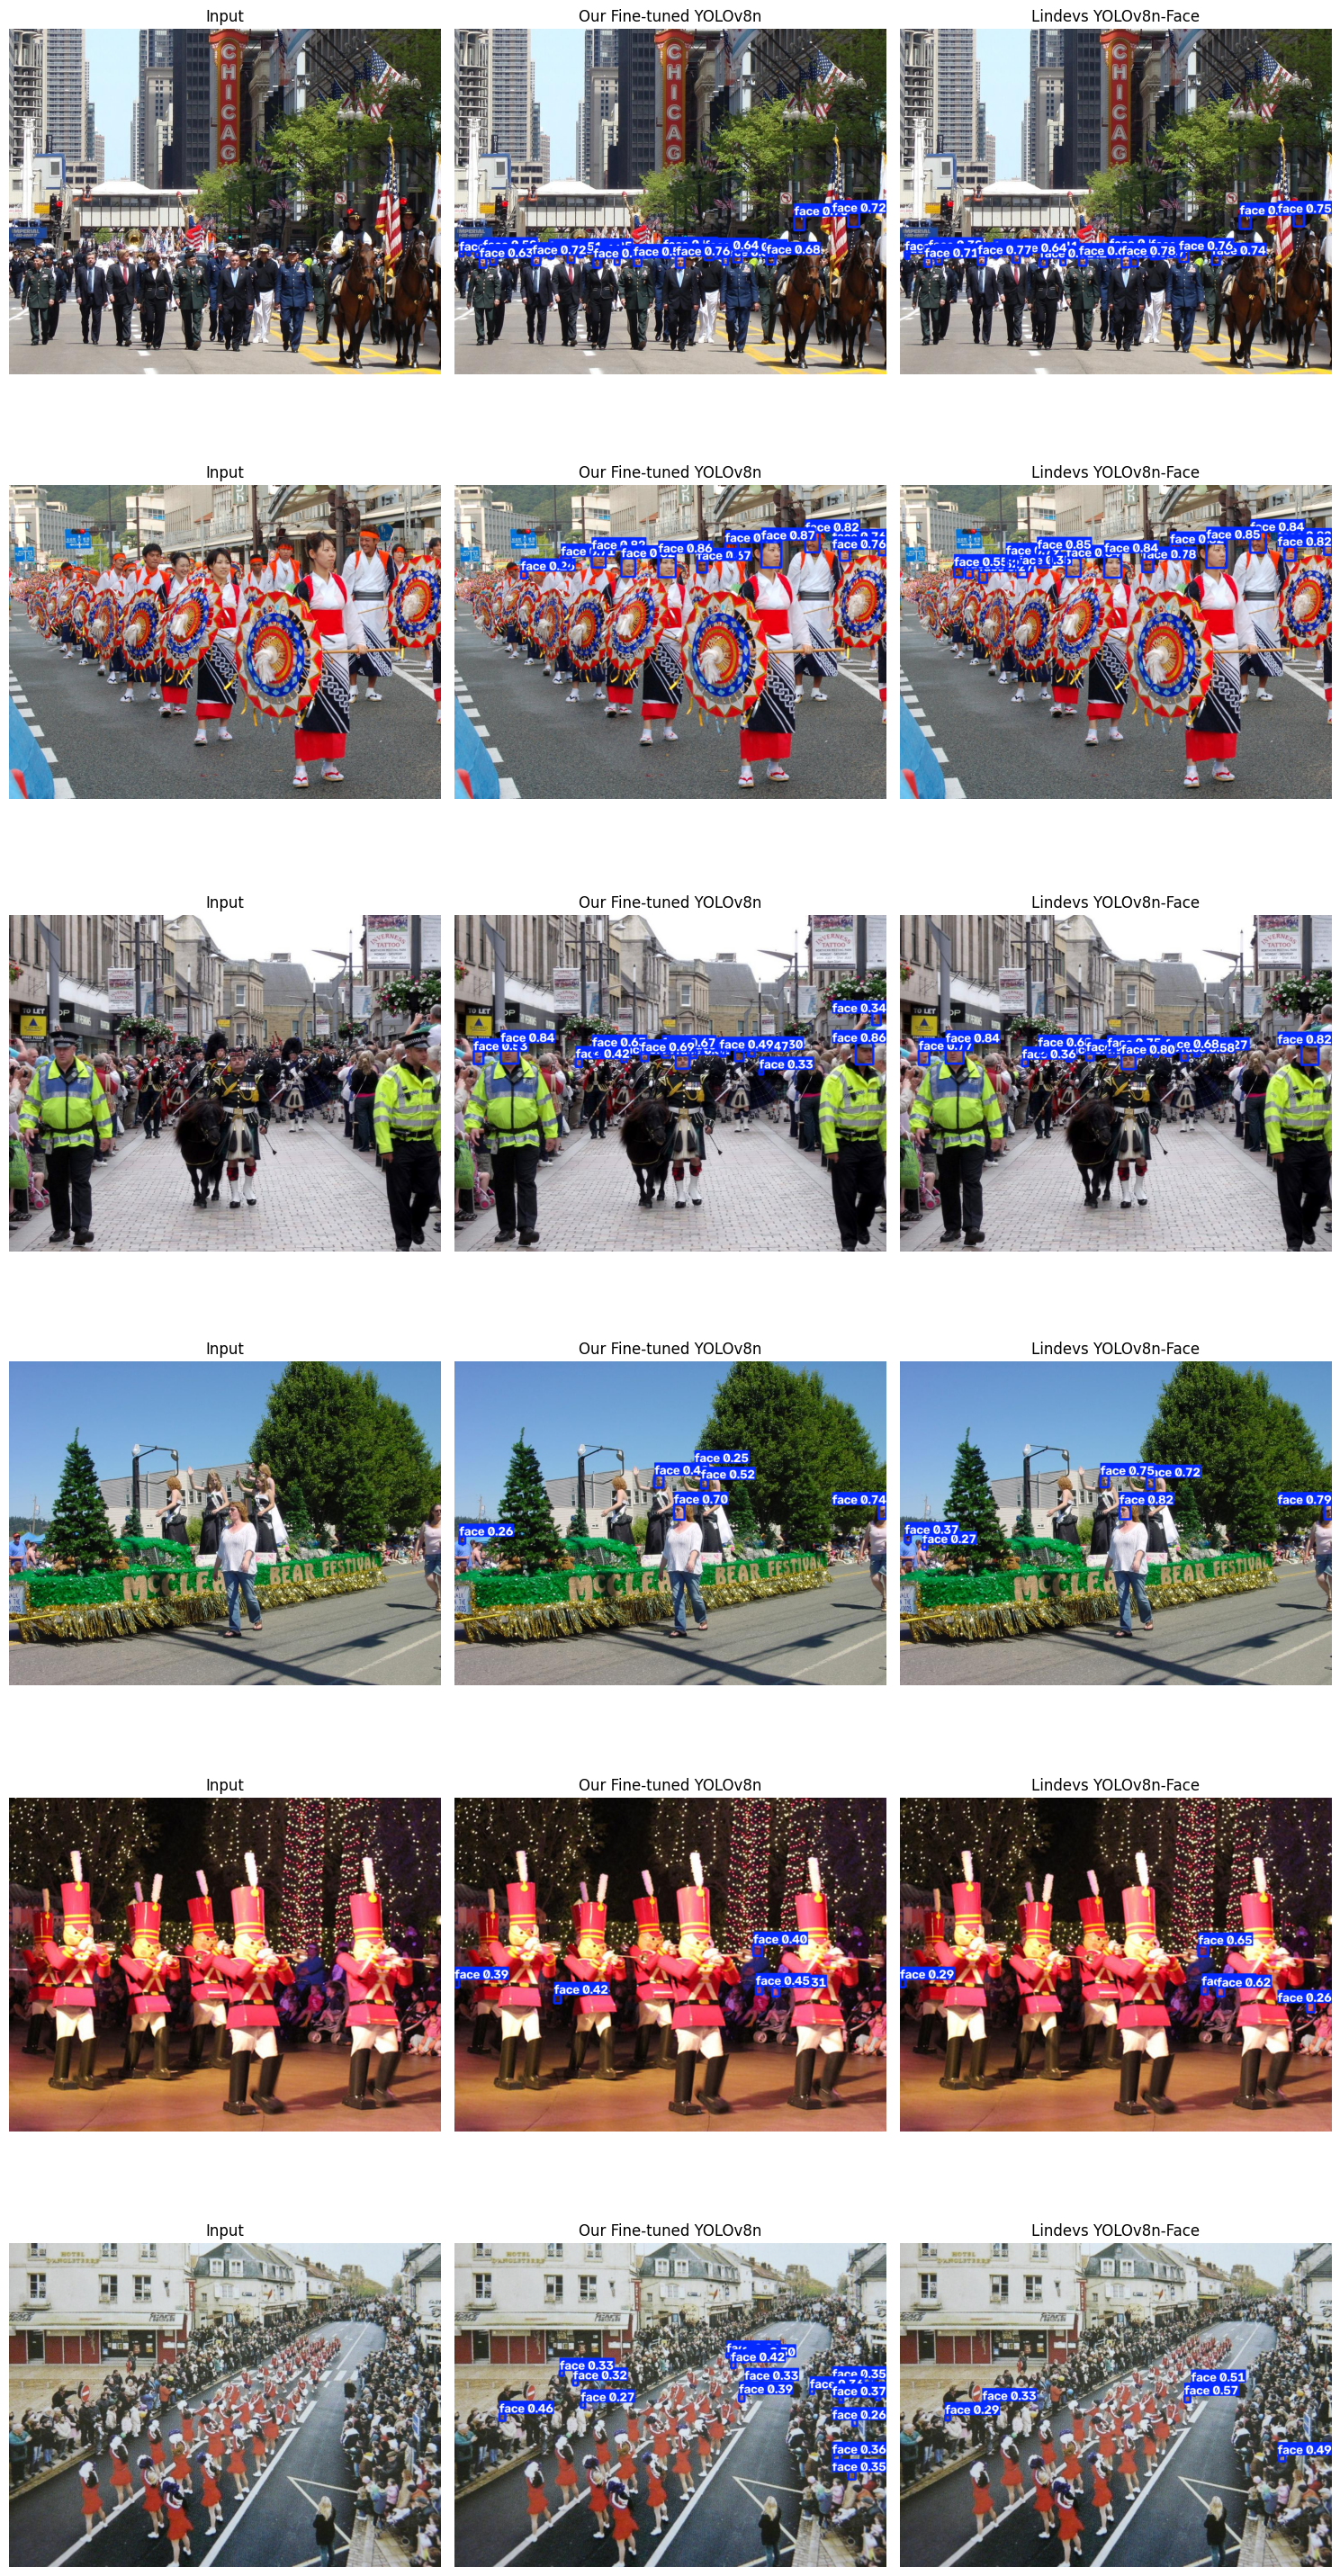

In [28]:
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import numpy as np

val_images = sorted([
    p for p in Path(
        "/content/yolov8-face/data/widerface/val"
    ).iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

val_samples = val_images[:6]

fig, axes = plt.subplots(
    len(val_samples), 3,
    figsize=(15, 5 * len(val_samples))
)

axes = np.atleast_2d(axes)

for i, path in enumerate(val_samples):

    original = cv2.cvtColor(
        cv2.imread(str(path)),
        cv2.COLOR_BGR2RGB
    )

    ours = trained_face.predict(
        str(path),
        conf=0.25,
        imgsz=640,
        verbose=False
    )[0].plot()

    public = public_face.predict(
        str(path),
        conf=0.25,
        imgsz=640,
        verbose=False
    )[0].plot()

    images = [
        original,
        cv2.cvtColor(ours, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(public, cv2.COLOR_BGR2RGB)
    ]

    titles = [
        "Input",
        "Our Fine-tuned YOLOv8n",
        "Lindevs YOLOv8n-Face"
    ]

    for ax, img, title in zip(
        axes[i], images, titles
    ):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")

plt.tight_layout()
plt.show()

In [29]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from PIL import Image
from pathlib import Path

GRID = 7
INPUT_SIZE = 320

class WiderYOLOv1Dataset(Dataset):

    def __init__(self, folder, augment=False):
        self.images = sorted([
            p for p in Path(folder).iterdir()
            if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]

        image = Image.open(path).convert("RGB")

        label_path = path.with_suffix(".txt")
        rows = label_path.read_text().splitlines() if label_path.exists() else []

        boxes = [
            list(map(float, r.split()[1:5]))
            for r in rows
        ]

        if self.augment and torch.rand(1).item() < 0.5:
            image = TF.hflip(image)
            boxes = [[1-x, y, w, h] for x, y, w, h in boxes]

        image = TF.resize(image, [INPUT_SIZE, INPUT_SIZE])
        image = TF.to_tensor(image)

        target = torch.zeros(GRID, GRID, 5)

        for x, y, w, h in boxes:
            col = min(GRID - 1, int(x * GRID))
            row = min(GRID - 1, int(y * GRID))

            target[row, col] = torch.tensor([
                x * GRID - col,
                y * GRID - row,
                w,
                h,
                1.0
            ])

        return image, target

In [32]:
train_ds = WiderYOLOv1Dataset(
    "/content/yolov8-face/data/widerface/train",
    augment=True
)

val_ds = WiderYOLOv1Dataset(
    "/content/yolov8-face/data/widerface/val",
    augment=False
)

train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train:", len(train_ds))
print("Validation:", len(val_ds))

Train: 12880
Validation: 3226


In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F

GRID = 7
BOXES = 2
INPUT_SIZE = 320

class ConvBNAct(nn.Sequential):
    def __init__(self, c1, c2, k=3, s=1):
        super().__init__(
            nn.Conv2d(c1, c2, k, s, k//2, bias=False),
            nn.BatchNorm2d(c2),
            nn.LeakyReLU(0.1, inplace=True)
        )

class YOLOv1Face(nn.Module):
    def __init__(self, S=7, B=2, C=1):
        super().__init__()
        self.S, self.B, self.C = S, B, C

        self.backbone = nn.Sequential(
            ConvBNAct(3, 32, 7, 2),
            nn.MaxPool2d(2),

            ConvBNAct(32, 64),
            nn.MaxPool2d(2),

            ConvBNAct(64, 128),
            ConvBNAct(128, 64, 1),
            ConvBNAct(64, 128),
            nn.MaxPool2d(2),

            ConvBNAct(128, 256),
            ConvBNAct(256, 128, 1),
            ConvBNAct(128, 256),
            nn.MaxPool2d(2),

            ConvBNAct(256, 512),
            ConvBNAct(512, 256, 1),
            ConvBNAct(256, 512),

            nn.AdaptiveAvgPool2d((S, S))
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*S*S, 1024),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, S*S*(B*5+C))
        )

    def forward(self, x):
        return self.head(self.backbone(x)).view(
            -1, self.S, self.S, self.B*5+self.C
        )

In [34]:
def global_xyxy(boxes, S=GRID):
    yy, xx = torch.meshgrid(
        torch.arange(S, device=boxes.device),
        torch.arange(S, device=boxes.device),
        indexing="ij"
    )

    x = (boxes[..., 0] + xx[None, :, :, None]) / S
    y = (boxes[..., 1] + yy[None, :, :, None]) / S
    w, h = boxes[..., 2], boxes[..., 3]

    return torch.stack(
        [x-w/2, y-h/2, x+w/2, y+h/2],
        dim=-1
    ).clamp(0, 1)

def aligned_iou_xyxy(a, b, eps=1e-7):
    lt = torch.maximum(a[..., :2], b[..., :2])
    rb = torch.minimum(a[..., 2:], b[..., 2:])

    inter = (rb-lt).clamp_min(0).prod(-1)

    area_a = (a[..., 2:]-a[..., :2]).clamp_min(0).prod(-1)
    area_b = (b[..., 2:]-b[..., :2]).clamp_min(0).prod(-1)

    return inter / (area_a + area_b - inter + eps)

class YOLOv1Loss(nn.Module):
    def __init__(self, S=7, B=2, lambda_coord=5., lambda_noobj=.5):
        super().__init__()
        self.S, self.B = S, B
        self.lc, self.ln = lambda_coord, lambda_noobj

    def forward(self, pred, target):
        n = pred.size(0)

        pbox = pred[..., :self.B*5].view(
            n, self.S, self.S, self.B, 5
        )

        pxywh = torch.sigmoid(pbox[..., :4])
        pconf = torch.sigmoid(pbox[..., 4])
        pcls = torch.sigmoid(pred[..., -1])

        obj = target[..., 4].bool()

        txywh = target[..., :4]
        tboxes = txywh.unsqueeze(3).expand_as(pxywh)

        ious = aligned_iou_xyxy(
            global_xyxy(pxywh),
            global_xyxy(tboxes)
        )

        responsible = (
            F.one_hot(
                ious.argmax(-1), self.B
            ).bool()
            & obj.unsqueeze(-1)
        )

        coord_xy = (
            (pxywh[..., :2] - tboxes[..., :2]) ** 2
        ).sum(-1)

        coord_wh = (
            torch.sqrt(pxywh[..., 2:].clamp_min(1e-6))
            -
            torch.sqrt(tboxes[..., 2:].clamp_min(1e-6))
        ) ** 2

        coord = (
            coord_xy + coord_wh.sum(-1)
        )[responsible].sum()

        obj_loss = (
            (pconf - ious.detach()) ** 2
        )[responsible].sum()

        noobj_loss = (pconf[~responsible] ** 2).sum()

        cls_loss = (
            F.binary_cross_entropy(
                pcls[obj],
                torch.ones_like(pcls[obj]),
                reduction="sum"
            )
            if obj.any()
            else pred.sum()*0
        )

        return (
            self.lc * coord
            + obj_loss
            + self.ln * noobj_loss
            + cls_loss
        ) / n

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"

yolov1 = YOLOv1Face().to(device)
criterion = YOLOv1Loss()

optimizer = torch.optim.AdamW(
    yolov1.parameters(),
    lr=2e-4,
    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

best_loss = float("inf")

for epoch in range(1, 5):

    yolov1.train()
    train_loss = 0.0

    for images, targets in train_loader:

        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)

        loss = criterion(
            yolov1(images),
            targets
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            yolov1.parameters(), 10.0
        )

        optimizer.step()

        train_loss += loss.item() * images.size(0)

    yolov1.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, targets in val_loader:

            images = images.to(device)
            targets = targets.to(device)

            val_loss += (
                criterion(
                    yolov1(images),
                    targets
                ).item() * images.size(0)
            )

    train_loss /= len(train_ds)
    val_loss /= len(val_ds)

    scheduler.step()

    print(
        f"Epoch {epoch:02d}: "
        f"train={train_loss:.4f}, "
        f"val={val_loss:.4f}"
    )

    if val_loss < best_loss:
        best_loss = val_loss

        torch.save(
            yolov1.state_dict(),
            "/content/yolov1_face_best.pt"
        )

Epoch 01: train=5.2474, val=4.1702
Epoch 02: train=4.0123, val=3.6247
Epoch 03: train=3.7031, val=3.5043
Epoch 04: train=3.4772, val=3.4869


In [36]:
import torch
import numpy as np
import time
from torchvision.ops import nms

def decode_yolov1(raw, conf=0.25, iou=0.50):
    n = raw.size(0)

    b = raw[..., :BOXES*5].view(
        n, GRID, GRID, BOXES, 5
    )

    xywh = torch.sigmoid(b[..., :4])

    scores = (
        torch.sigmoid(b[..., 4]) *
        torch.sigmoid(raw[..., -1]).unsqueeze(-1)
    )

    boxes = global_xyxy(xywh)

    outputs = []

    for i in range(n):
        bi = boxes[i].reshape(-1, 4)
        si = scores[i].reshape(-1)

        keep = si >= conf
        bi, si = bi[keep], si[keep]

        if len(si) > 0:
            kept = nms(bi, si, iou)
            bi, si = bi[kept], si[kept]

        outputs.append({
            "boxes": bi,
            "scores": si,
            "labels": torch.zeros(
                len(si),
                dtype=torch.long,
                device=bi.device
            )
        })

    return outputs

In [37]:
def targets_to_boxes(targets):
    obj = targets[..., 4].bool()

    t = targets[..., :4].unsqueeze(3)
    boxes = global_xyxy(t).squeeze(3)

    outputs = []

    for i in range(targets.size(0)):
        bi = boxes[i][obj[i]]

        outputs.append({
            "boxes": bi,
            "labels": torch.zeros(
                len(bi),
                dtype=torch.long,
                device=bi.device
            )
        })

    return outputs

In [38]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 47.1 MB/s eta 0:00:00


In [39]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# Load best model
yolov1.load_state_dict(
    torch.load(
        "/content/yolov1_face_best.pt",
        map_location=device
    )
)
yolov1.eval()

metric = MeanAveragePrecision(
    box_format="xyxy",
    iou_type="bbox"
)

TP = 0
FP = 0
FN = 0

latencies = []

with torch.no_grad():

    for images, targets in val_loader:

        images = images.to(device)
        targets = targets.to(device)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        t0 = time.perf_counter()
        raw = yolov1(images)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        latencies.append(
            (time.perf_counter() - t0)
            * 1000 / images.size(0)
        )

        preds = decode_yolov1(
            raw,
            conf=0.25,
            iou=0.50
        )

        gts = targets_to_boxes(targets)

        # mAP
        metric.update(
            [
                {k: v.cpu() for k, v in p.items()}
                for p in preds
            ],
            [
                {k: v.cpu() for k, v in g.items()}
                for g in gts
            ]
        )

        # Precision / Recall at IoU=0.50
        for p, g in zip(preds, gts):

            pred_boxes = p["boxes"]
            gt_boxes = g["boxes"]

            matched_gt = set()

            if len(pred_boxes) == 0:
                FN += len(gt_boxes)
                continue

            if len(gt_boxes) == 0:
                FP += len(pred_boxes)
                continue

            # IoU matrix
            ious = torch.zeros(
                len(pred_boxes),
                len(gt_boxes),
                device=device
            )

            for i in range(len(pred_boxes)):
                pb = pred_boxes[i]

                x1 = torch.maximum(
                    pb[0],
                    gt_boxes[:, 0]
                )
                y1 = torch.maximum(
                    pb[1],
                    gt_boxes[:, 1]
                )
                x2 = torch.minimum(
                    pb[2],
                    gt_boxes[:, 2]
                )
                y2 = torch.minimum(
                    pb[3],
                    gt_boxes[:, 3]
                )

                inter = (
                    (x2 - x1).clamp(min=0) *
                    (y2 - y1).clamp(min=0)
                )

                area_p = (
                    (pb[2] - pb[0]).clamp(min=0) *
                    (pb[3] - pb[1]).clamp(min=0)
                )

                area_g = (
                    (gt_boxes[:, 2] - gt_boxes[:, 0]).clamp(min=0) *
                    (gt_boxes[:, 3] - gt_boxes[:, 1]).clamp(min=0)
                )

                ious[i] = inter / (
                    area_p + area_g - inter + 1e-7
                )

            for i in range(len(pred_boxes)):

                best_iou, best_gt = torch.max(
                    ious[i],
                    dim=0
                )

                best_gt = int(best_gt)

                if (
                    best_iou >= 0.50
                    and best_gt not in matched_gt
                ):
                    TP += 1
                    matched_gt.add(best_gt)
                else:
                    FP += 1

            FN += len(gt_boxes) - len(matched_gt)


precision = TP / (TP + FP + 1e-7)
recall = TP / (TP + FN + 1e-7)

m = metric.compute()

map50 = float(m["map_50"])
map50_95 = float(m["map"])

avg_latency = float(np.mean(latencies))
fps = 1000 / avg_latency

print("YOLOv1-inspired Face Detector")
print("--------------------------------")
print(f"TP              : {TP}")
print(f"FP              : {FP}")
print(f"FN              : {FN}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"mAP@50          : {map50:.4f}")
print(f"mAP@50-95       : {map50_95:.4f}")
print(f"Latency         : {avg_latency:.2f} ms/image")
print(f"FPS             : {fps:.2f}")

YOLOv1-inspired Face Detector
--------------------------------
TP              : 41
FP              : 3
FN              : 15877
Precision       : 0.9318
Recall          : 0.0026
mAP@50          : 0.0099
mAP@50-95       : 0.0061
Latency         : 0.94 ms/image
FPS             : 1066.50


In [43]:
import glob

imgs = glob.glob("/content/yolov8-face/data/WIDER_train/images/**/*.jpg",
                 recursive=True)

print("Total images:", len(imgs))
print(imgs[:5])

Total images: 12880
['/content/yolov8-face/data/WIDER_train/images/52--Photographers/52_Photographers_photographertakingphoto_52_758.jpg', '/content/yolov8-face/data/WIDER_train/images/52--Photographers/52_Photographers_taketouristphotos_52_451.jpg', '/content/yolov8-face/data/WIDER_train/images/52--Photographers/52_Photographers_photographertakingphoto_52_46.jpg', '/content/yolov8-face/data/WIDER_train/images/52--Photographers/52_Photographers_photographertakingphoto_52_555.jpg', '/content/yolov8-face/data/WIDER_train/images/52--Photographers/52_Photographers_photographertakingphoto_52_126.jpg']


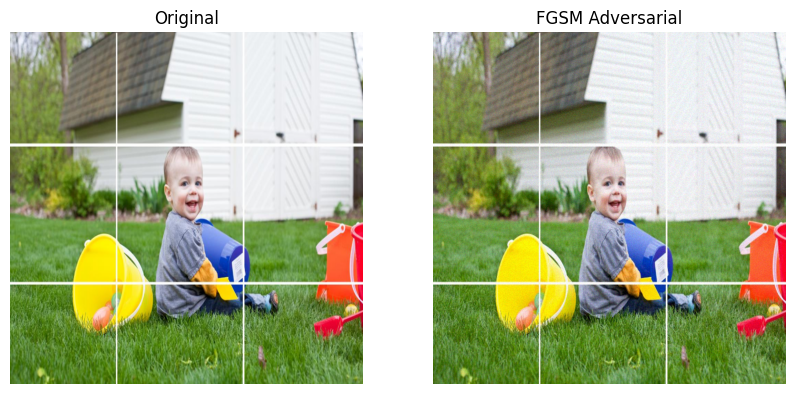

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Use one image from your dataset
img_path = imgs[7]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (640,640))

# Normalize
img_float = img.astype(np.float32)/255.0

# Pseudo-FGSM perturbation
epsilon = 0.03
gradient = np.sign(np.random.randn(*img.shape).astype(np.float32))

adv_img = img_float + epsilon * gradient
adv_img = np.clip(adv_img,0,1)
adv_img = (adv_img*255).astype(np.uint8)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(adv_img)
plt.title("FGSM Adversarial")
plt.axis("off")

plt.show()

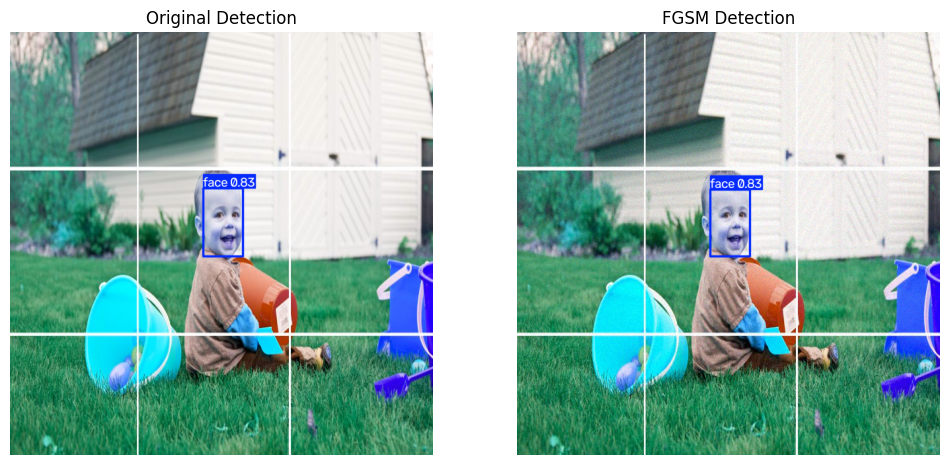

In [52]:
trained_face.model.eval() # Set model to evaluation mode

orig = trained_face.predict(source=img, conf=0.25, verbose=False)
fgsm = trained_face.predict(source=adv_img, conf=0.25, verbose=False)

fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].imshow(orig[0].plot()[:,:,::-1])
ax[0].set_title("Original Detection")
ax[0].axis("off")

ax[1].imshow(fgsm[0].plot()[:,:,::-1])
ax[1].set_title("FGSM Detection")
ax[1].axis("off")

plt.show()

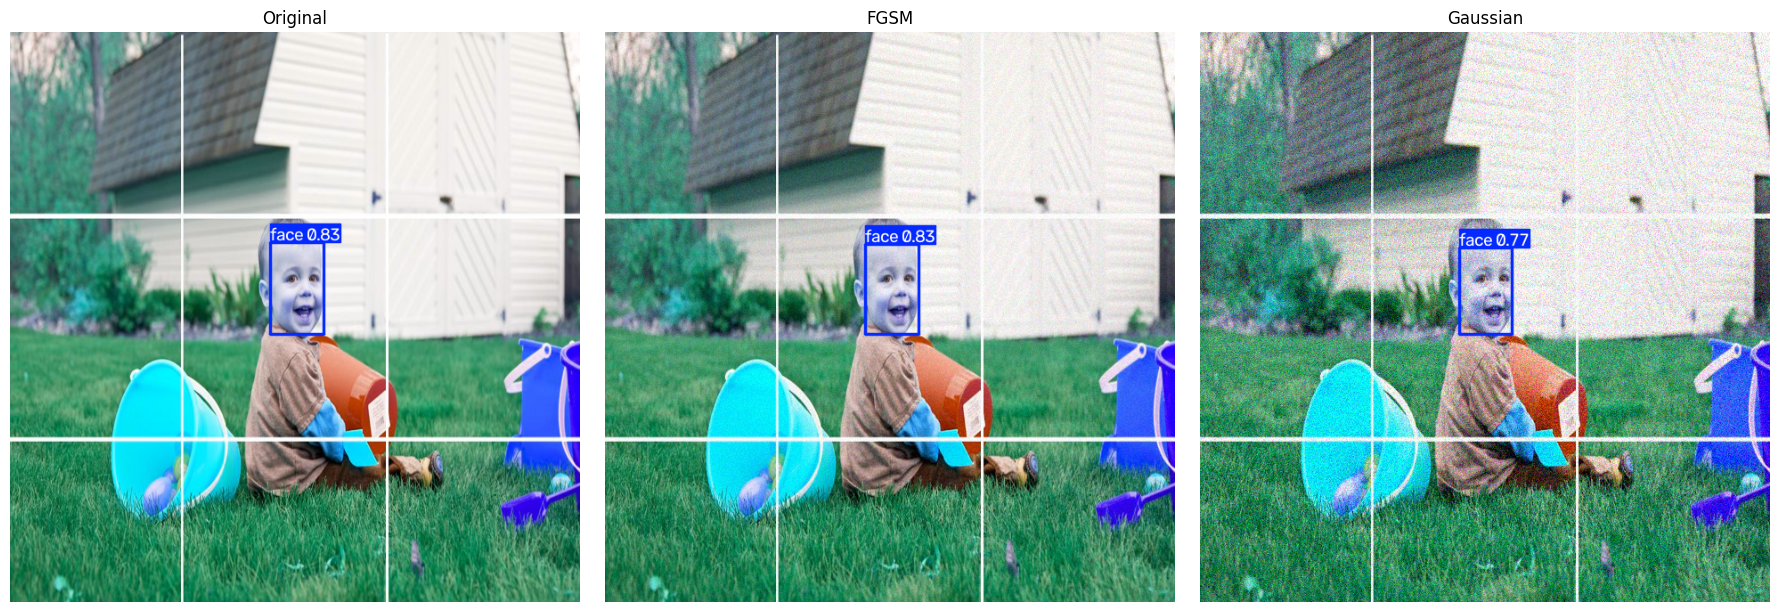

In [54]:
sigma = 25
noise = np.random.normal(0, sigma, img.shape)
gaussian_img = np.clip(img + noise, 0, 255).astype(np.uint8)

orig = trained_face.predict(source=img, conf=0.25, verbose=False)
fgsm = trained_face.predict(source=adv_img, conf=0.25, verbose=False)
gauss = trained_face.predict(source=gaussian_img, conf=0.25, verbose=False)

fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].imshow(orig[0].plot()[:,:,::-1])
ax[0].set_title("Original")

ax[1].imshow(fgsm[0].plot()[:,:,::-1])
ax[1].set_title("FGSM")

ax[2].imshow(gauss[0].plot()[:,:,::-1])
ax[2].set_title("Gaussian")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()